# Nairobi urban flood risk model (Team A, ML component)

Chain: **Hazard → Vulnerability → Exposure → Financial engine → EP curve**, plus an ML hotspot layer that
changes the hazard. Model logic lives in `src/`; this notebook runs it and shows the results.

> Exposure is **synthetic** and hazard is a **terrain proxy**. No number below is an observed loss.
> Assumptions: `src/config.py` and `outputs/assumptions.json`.

**Key assumptions** – the five rasters are nested views of one surface S, so the smallest footprint
(*extreme*) is the most frequent scenario (RP5) and the largest (*common*) is RP250; depth = 4 m × max(0, S − t);
vulnerability = JRC Africa residential curve adapted per housing class.

## 1. Setup and run

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); warnings.filterwarnings("ignore")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40); pd.set_option("display.float_format", "{:,.4g}".format)

from src import config, hazard, risk, vulnerability, plots, pipeline
plots.style()
res = pipeline.run_pipeline()          # loads Dataset/, trains, validates, computes losses (~2 min, seeded)
exposure, summary, hotspots = res["exposure"], res["summary"], res["hotspots"]

[data] 600 buildings, 24 hotspots, 5 rasters
[hazard] inferred tier thresholds: {'common': 0.0, 'occasional': 0.0862, 'moderate': 0.1729, 'severe': 0.2805, 'extreme': 0.3742}


[ml] training set: 24 hotspots vs 451 background buildings, 15 features


[ml] cross-validation done; selected model: logistic_regression


[ml] hotspot recall baseline 0.50 -> ML (LOO) 0.54; FPR baseline 0.37 -> ML 0.41
[hazard] S_ref=0.420; buildings with hazard: proxy 259 -> +known hotspots 318 -> +ML 398


[done] 91.8s; portfolio AAL baseline KES 272,113,880 -> augmented KES 607,333,848


## 2. Exposure and hotspot baseline

,buildings,total_tiv_kes,mean_tiv_kes,mean_floor_area_m2,share_of_tiv
housing_class,,,,,
concrete_rcc,84,5.414e+10,6.445e+08,918,0.8507
permanent_masonry,156,8.451e+09,5.417e+07,107,0.1328
semi_permanent,181,8.507e+08,4.7e+06,39.51,0.01337
informal_iron_sheet,179,1.981e+08,1.107e+06,14.7,0.003113


Baseline rule (proxy at point > 0) flags 12 of 24 known hotspots


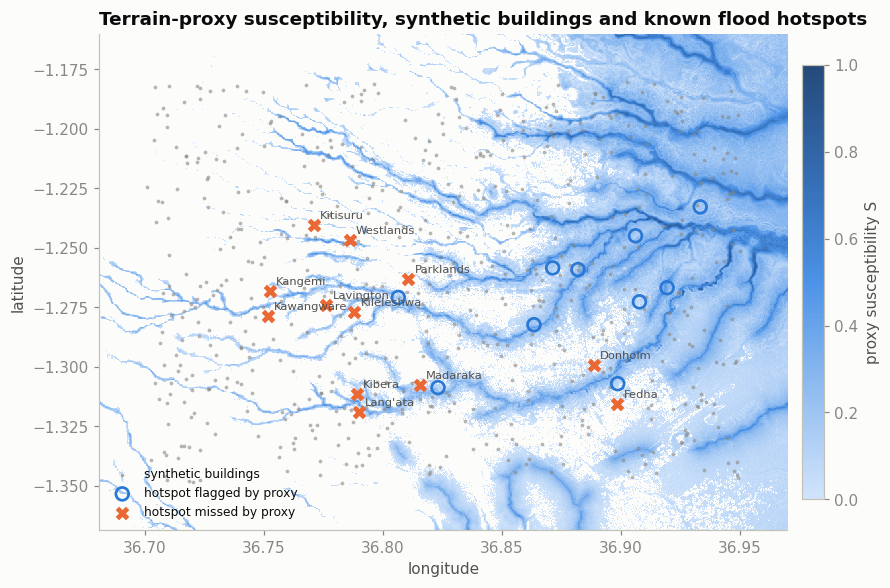

In [2]:
from src import exposure as expo
display(expo.exposure_summary(exposure))
hv = res["hotspot_validation"]
print(f"Baseline rule (proxy at point > 0) flags {hv.baseline_flagged.sum()} of {len(hv)} known hotspots")
r = res["rasters"]["common"]; extent = (r.x_origin, r.x_origin + r.shape[1]*r.x_res, r.y_origin - r.shape[0]*r.y_res, r.y_origin)
plots.hotspot_map(r.values, extent, exposure, hotspots, hv);

## 3. Vulnerability
`damage_ratio = min(cap, JRC(depth × multiplier))` per housing class.

,depth_multiplier,max_damage_ratio,rationale
informal_iron_sheet,1.5,0.95,"single-storey, light materials, contents at fl..."
semi_permanent,1.2,0.9,"mixed materials, limited water resistance"
permanent_masonry,1,0.85,reference class: closest to JRC residential bu...
concrete_rcc,0.7,0.8,often multi-storey; only lower floors affected


,RP5,RP10,RP25,RP100,RP250
housing_class,,,,,
informal_iron_sheet,0,0,0.23,0.395,0.545
semi_permanent,0,0,0.187,0.329,0.456
permanent_masonry,0,0,0.156,0.284,0.394
concrete_rcc,0,0,0.109,0.216,0.294


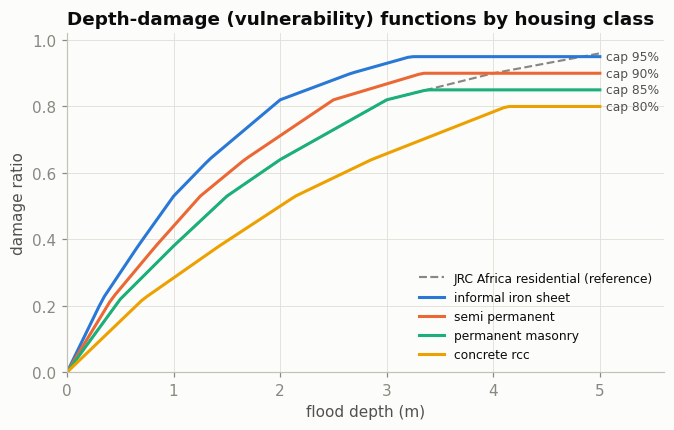

In [3]:
display(pd.DataFrame(config.HOUSING_CLASS_VULNERABILITY).T)
plots.vulnerability_curves(vulnerability.vulnerability_curves());
display(res["vulnerability_matrix"].round(3))

## 4. Hotspot model validation
24 positives, so: 5-fold stratified CV repeated 10×, leave-one-out scoring of every hotspot, and two baselines
(point rule; max within 500 m). Raw-coordinate variants are shown only to document why they were rejected
(they memorise where known hotspots are).

selected model: logistic_regression


,roc_auc_mean,average_precision_mean,recall_mean,false_positive_rate_mean
model,,,,
logistic_regression,0.687,0.157,0.552,0.383
random_forest,0.678,0.116,0,0.002
hist_gradient_boosting,0.704,0.154,0.17,0.091
baseline_point_proxy,0.561,0.063,0.496,0.375
baseline_max_500m,0.681,0.104,0.374,0.217
logistic_regression+latlon,0.726,0.227,0.562,0.338
random_forest+latlon,0.849,0.326,0.02,0.005
hist_gradient_boosting+latlon,0.85,0.45,0.498,0.052


hotspots_recovered_by_ml_missed_by_baseline: ['Donholm', 'Madaraka', "Lang'ata", 'Kileleshwa', 'Kibera']
hotspots_lost_by_ml_flagged_by_baseline: ['Kiambiu', 'Kayole', 'Nairobi West', 'Chiromo']
hotspots_missed_by_both: ['Fedha', 'Kawangware', 'Kangemi', 'Lavington', 'Westlands', 'Parklands', 'Kitisuru']


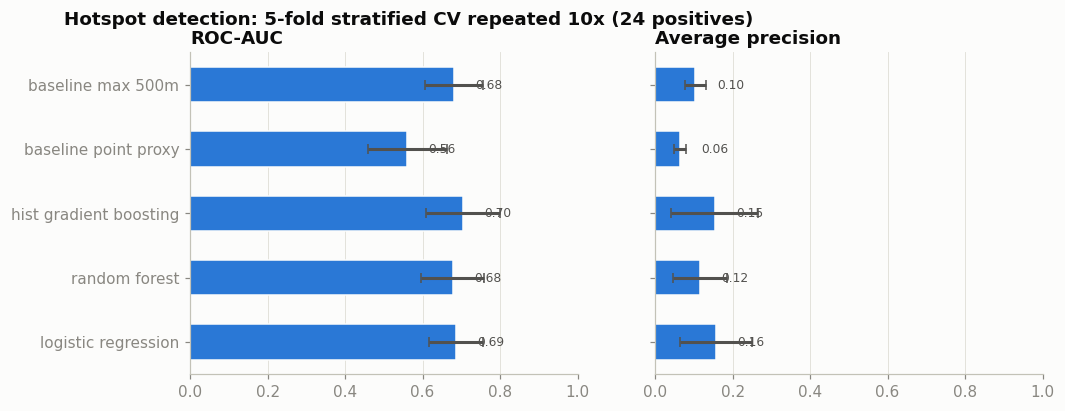

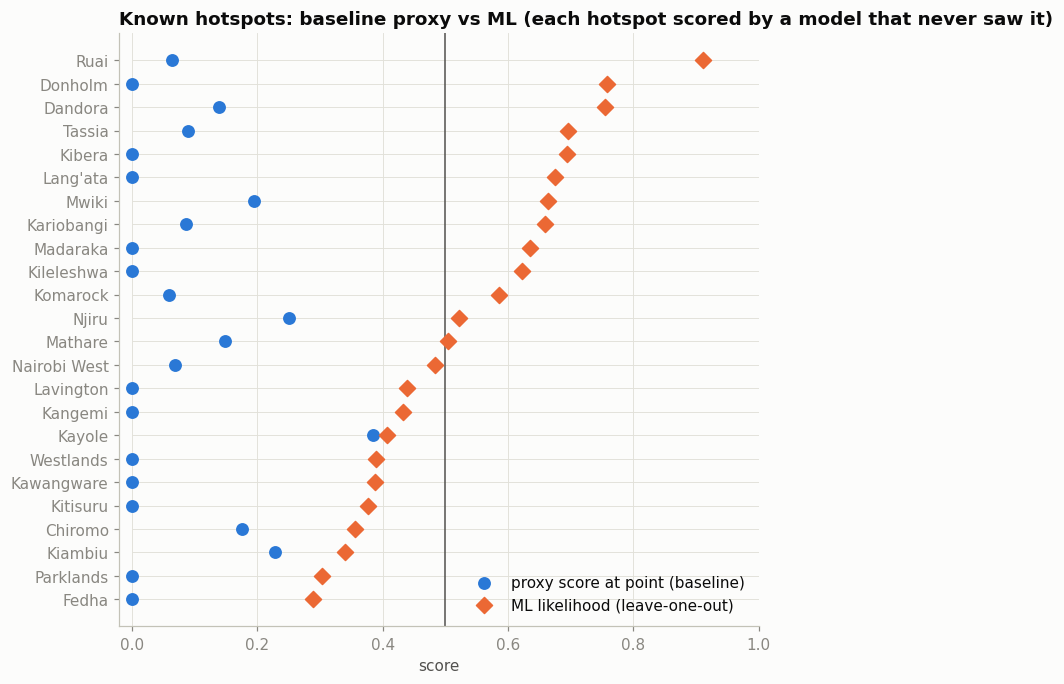

In [4]:
cv = res["cv_results"]; hm = res["hotspot_metrics"]
print("selected model:", res["chosen_model"])
display(cv[[c for c in cv.columns if c.endswith("_mean")]].round(3))
plots.cv_comparison(cv);
plots.baseline_vs_ml_hotspots(hv);
for k in ["hotspots_recovered_by_ml_missed_by_baseline", "hotspots_lost_by_ml_flagged_by_baseline", "hotspots_missed_by_both"]:
    print(f"{k}: {hm[k]}")

**Reading it honestly.** Proxy-derived features reach ROC-AUC ≈ 0.7, no better than the simple 500 m heuristic and
well above the point rule (0.56). The ML recovers 5 hotspots the proxy misses, loses 4 it hits, and 7 western
hotspots are missed by both: the proxy cannot see drainage. ML uplift is therefore labelled low confidence.

## 5. Scenarios, EP curve and expected loss
Three nested hazard layers through the same engine: proxy only → + known hotspots → + ML (adopted).

,scenario,return_period_years,exceedance_probability,footprint_tier,susceptibility_threshold,max_depth_m
0,RP5,5,0.2,extreme,0.3742,2.503
1,RP10,10,0.1,severe,0.2805,2.878
2,RP25,25,0.04,moderate,0.1729,3.308
3,RP100,100,0.01,occasional,0.08623,3.655
4,RP250,250,0.004,common,0,4


,AAL (KES),AAL rate
baseline_proxy,2.721e+08,0.004276
proxy_plus_hotspots,3.455e+08,0.00543
ml_augmented,6.073e+08,0.009544


scenario,housing_class,total_tiv_kes,RP5,RP10,RP25,RP100,RP250,expected_annual_loss_kes,aal_rate
0,concrete_rcc,5.414e+10,2.84e+08,1.039e+09,4.032e+09,6.915e+09,9.704e+09,4.712e+08,0
1,informal_iron_sheet,1.981e+08,3.431e+06,8.32e+06,3.027e+07,4.82e+07,6.542e+07,3.525e+06,0
2,permanent_masonry,8.451e+09,1.163e+08,3.119e+08,1.017e+09,1.605e+09,2.152e+09,1.205e+08,0
3,semi_permanent,8.507e+08,6.383e+06,2.595e+07,1.07e+08,1.784e+08,2.492e+08,1.217e+07,0


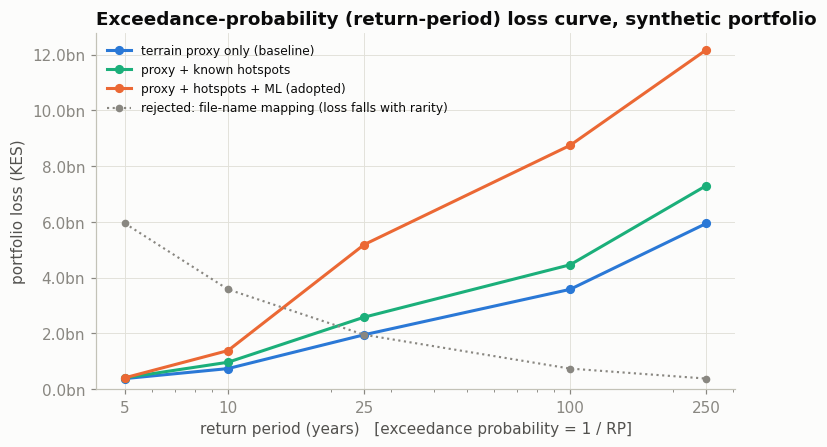

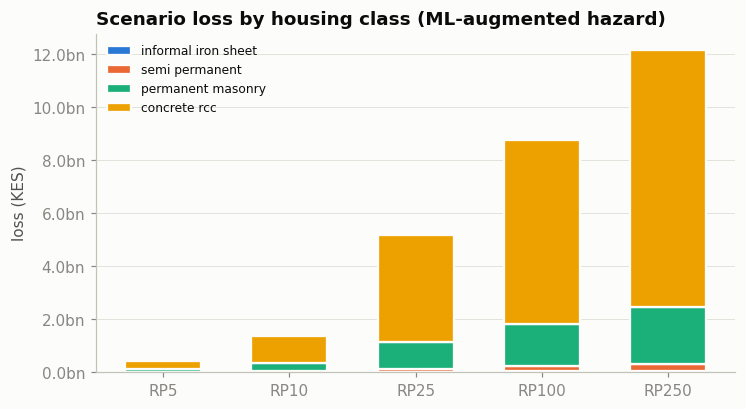

In [5]:
display(res["scenarios"])
plots.ep_curves(res["ep_baseline"], res["ep_hotspots"], res["ep_augmented"], res["ep_naive_mapping"]);
aal = {k: risk.average_annual_loss(e.portfolio_loss_kes.values, e.exceedance_probability.values)
       for k, e in [("baseline_proxy", res["ep_baseline"]), ("proxy_plus_hotspots", res["ep_hotspots"]), ("ml_augmented", res["ep_augmented"])]}
display(pd.DataFrame({"AAL (KES)": aal, "AAL rate": {k: v / expo.total_exposure(exposure) for k, v in aal.items()}}))
display(res["loss_by_class"].round(0))
plots.loss_by_scenario_and_class(res["loss_by_class"], list(res["scenarios"].scenario));

In [6]:
# Sensitivity of the result to the ML flag threshold
s_proxy = exposure[config.HAZARD_COLUMNS["common"]].values
sm = summary.set_index("building_id").loc[exposure.building_id]
rows = []
for thr in [0.5, 0.6, 0.7, 0.8, 1.01]:
    s_aug, _ = hazard.augment_susceptibility(s_proxy, sm.ml_hotspot_likelihood.values, sm.hotspot_proximity.values, res["s_reference"], ml_threshold=thr)
    e = risk.ep_curve(risk.scenario_losses(exposure, s_aug, res["scenarios"]))
    rows.append({"ml_flag_threshold": thr if thr <= 1 else "ML off", "buildings_with_hazard": int((s_aug > 0).sum()),
                 "AAL_kes": risk.average_annual_loss(e.portfolio_loss_kes.values, e.exceedance_probability.values),
                 "RP100_loss_kes": float(e.loc[e.return_period_years == 100, "portfolio_loss_kes"].iloc[0])})
pd.DataFrame(rows)

,ml_flag_threshold,buildings_with_hazard,AAL_kes,RP100_loss_kes
0,0.5,398,6.073e+08,8.747e+09
1,0.6,362,5.158e+08,6.777e+09
2,0.7,336,4.643e+08,5.83e+09
3,0.8,325,4.038e+08,5.046e+09
4,ML off,318,3.455e+08,4.462e+09


## 6. Risk ranking
`risk_score` = percentile of annual loss rate (AAL / TIV); `rank_by_expected_loss` ranks absolute AAL.

,building_id,housing_class,tiv_kes,hazard_source,proxy_susceptibility,ml_hotspot_likelihood,annual_flood_probability,expected_annual_loss_kes,risk_score,risk_class,confidence
0,NBO-0316,concrete_rcc,5.226e+08,proxy,0.6274,0.0972,0.2,4.103e+07,97,very_high,medium
1,NBO-0416,concrete_rcc,1.356e+09,ml_model,0.189,0.849,0.1,3.491e+07,82.2,high,low
2,NBO-0403,concrete_rcc,9.461e+08,known_hotspot,0.1412,0.7966,0.2,3.153e+07,89.8,high,high
3,NBO-0452,concrete_rcc,3.805e+08,proxy,0.61,0.1296,0.2,2.872e+07,96.7,very_high,medium
4,NBO-0151,concrete_rcc,1.109e+09,ml_model,0.0129,0.7906,0.1,2.383e+07,76.2,high,low
5,NBO-0311,concrete_rcc,7.437e+08,ml_model,0.1163,0.8188,0.1,1.753e+07,79.8,high,low
6,NBO-0200,concrete_rcc,7.895e+08,known_hotspot,0.0344,0.5408,0.1,1.466e+07,70.5,medium,high
7,NBO-0130,concrete_rcc,9.59e+08,proxy,0.292,0.6195,0.1,1.38e+07,59.3,medium,high
8,NBO-0466,concrete_rcc,5.262e+08,proxy,0.352,0.1089,0.1,1.314e+07,81.5,high,high
9,NBO-0533,concrete_rcc,4.857e+08,proxy,0.3583,0.316,0.1,1.262e+07,82.7,high,medium


confidence,high,low,medium
hazard_source,,,
known_hotspot,16,0,28
ml_model,4,233,0
none,0,0,202
proxy,18,0,99


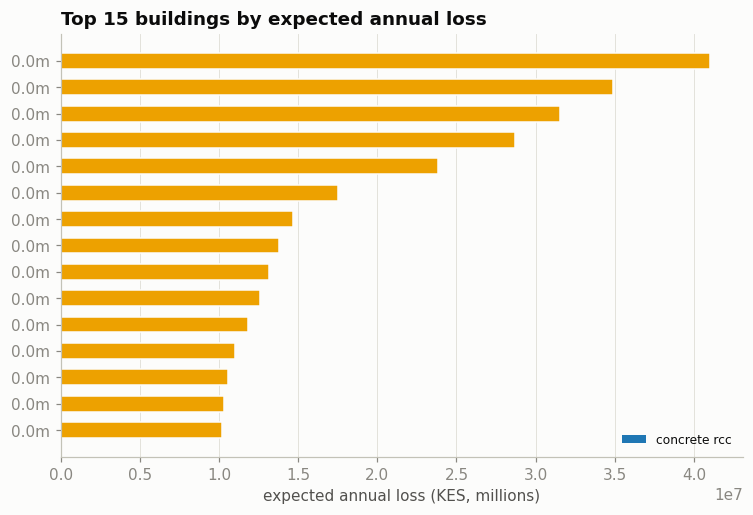

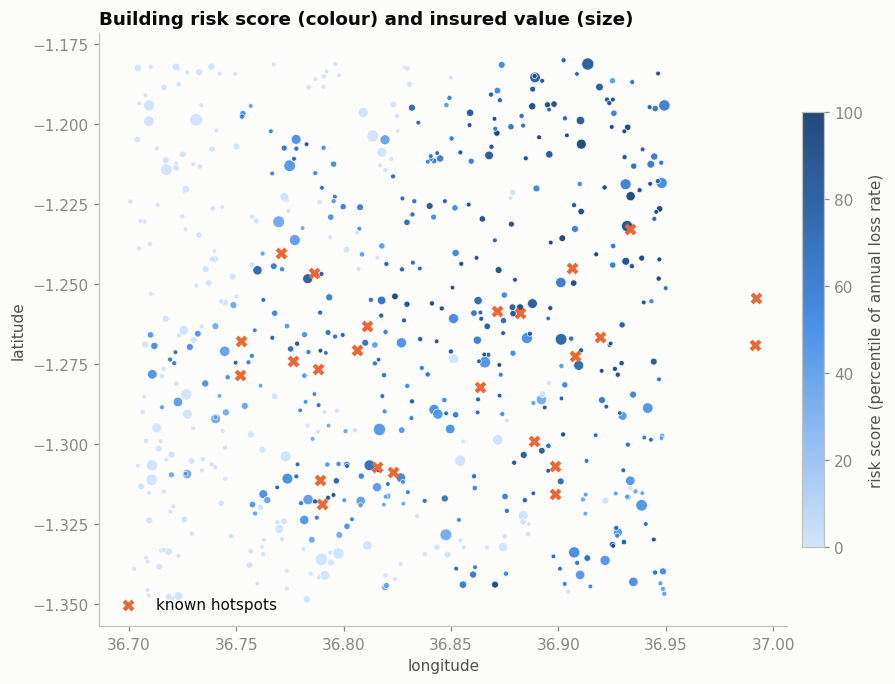

In [7]:
cols = ["building_id", "housing_class", "tiv_kes", "hazard_source", "proxy_susceptibility", "ml_hotspot_likelihood",
        "annual_flood_probability", "expected_annual_loss_kes", "risk_score", "risk_class", "confidence"]
display(summary[cols].head(10).round(4))
display(pd.crosstab(summary.hazard_source, summary.confidence))
plots.top_buildings(summary);
plots.risk_map(summary, hotspots);

## 7. Explainability
Permutation importance and SHAP for the hotspot model; a deterministic loss decomposition per building.

,feature,permutation_importance,permutation_std,standardised_coefficient
0,s_max_1000,0.076,0.018,1.125
1,frac_wet_500,0.071,0.02,0.775
2,dist_strong_m,0.05,0.033,-1.651
3,s_mean_500,0.042,0.023,0.358
4,s_mean_150,0.03,0.019,0.304
5,s_point,0.023,0.025,-0.824
6,dist_wet_m,0.014,0.02,-0.558
7,s_max_500,0.014,0.024,-0.366


NBO-0416 (concrete_rcc, Mwiki at 6,127 m)
  ML drivers: s_max_1000=0.797 (+1.72); dist_strong_m=68.7 (+1.34); frac_wet_500=1 (+1.28)
  loss drivers: hazard source: ml_model; annual flood probability 10% (top 16% of portfolio); insured value KES 1,356,500,000 (top 0%); concrete_rcc vulnerability cap 80%
NBO-0151 (concrete_rcc, Komarock at 935 m)
  ML drivers: frac_wet_500=0.988 (+1.26); dist_strong_m=264 (+1.03); frac_wet_150=1 (-0.69)
  loss drivers: hazard source: ml_model; annual flood probability 10% (top 16% of portfolio); insured value KES 1,108,710,000 (top 1%); concrete_rcc vulnerability cap 80%
NBO-0311 (concrete_rcc, Dandora at 6,876 m)
  ML drivers: s_max_1000=0.783 (+1.65); frac_wet_500=1 (+1.28); dist_strong_m=339 (+0.91)
  loss drivers: hazard source: ml_model; annual flood probability 10% (top 16% of portfolio); insured value KES 743,690,000 (top 5%); concrete_rcc vulnerability cap 80%


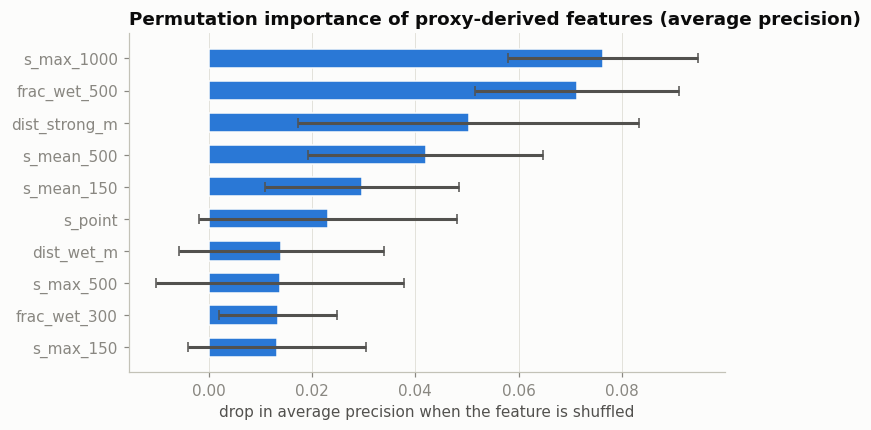

In [8]:
display(res["importance"].head(8).round(3))
plots.feature_importance(res["importance"]);
top = summary[summary.hazard_source == "ml_model"].head(3)
for _, r in top.iterrows():
    print(f"{r.building_id} ({r.housing_class}, {r.nearest_hotspot} at {r.nearest_hotspot_distance_m:,.0f} m)\n  ML drivers: {r.ml_risk_drivers}\n  loss drivers: {r.loss_drivers}")

## 8. Baseline vs ML-augmented

,baseline (proxy only),ML-augmented (adopted)
hotspots flagged (of 24),12,13
hotspot ROC-AUC,0.5638,0.6698
buildings with hazard,259,398
AAL (KES),2.721e+08,6.073e+08
RP100 (KES),3.581e+09,8.747e+09
RP250 (KES),5.946e+09,1.217e+10


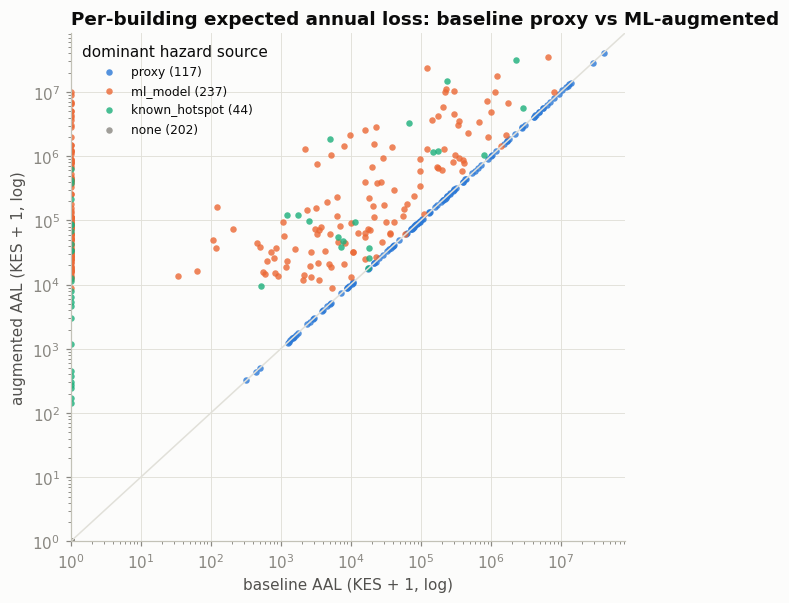

In [9]:
def rp(ep, n): return float(ep.loc[ep.return_period_years == n, "portfolio_loss_kes"].iloc[0])
cmp = pd.DataFrame({
    "baseline (proxy only)": {"hotspots flagged (of 24)": int(hv.baseline_flagged.sum()), "hotspot ROC-AUC": hm["baseline_roc_auc_point_score"],
        "buildings with hazard": int((summary.proxy_susceptibility > 0).sum()), "AAL (KES)": aal["baseline_proxy"],
        "RP100 (KES)": rp(res["ep_baseline"], 100), "RP250 (KES)": rp(res["ep_baseline"], 250)},
    "ML-augmented (adopted)": {"hotspots flagged (of 24)": int(hv.ml_flagged.sum()), "hotspot ROC-AUC": hm["ml_roc_auc_loo"],
        "buildings with hazard": int((summary.augmented_susceptibility > 0).sum()), "AAL (KES)": aal["ml_augmented"],
        "RP100 (KES)": rp(res["ep_augmented"], 100), "RP250 (KES)": rp(res["ep_augmented"], 250)}})
display(cmp)
plots.baseline_vs_ml_building_loss(summary);

**Limitations.** Synthetic exposure and proxy hazard; only 24 labelled hotspots (13 ungeocoded ones may sit in the
background set); the model cannot see drainage; return periods and the 4 m depth anchor are assumptions, so the EP
curve's shape is more reliable than its level; JRC values are transcribed and adapted; ground-up losses only.

## 9. Export

In [10]:
paths = pipeline.write_outputs(res)
pred = pd.read_csv(config.OUTPUT_DIR / "risk_predictions.csv")
assert list(pred.columns) == pipeline.RISK_PREDICTION_COLUMNS
assert np.allclose(pred.expected_loss_kes, pred.damage_ratio * pred.exposure_kes)
print(len(paths), "files written to outputs/;", pred.shape, "rows in risk_predictions.csv")
pred.head(5)

16 files written to outputs/; (3000, 24) rows in risk_predictions.csv


,building_id,latitude,longitude,housing_class,scenario,return_period_years,exceedance_probability,exposure_kes,flood_probability,hazard_source,proxy_susceptibility,ml_hotspot_likelihood,ml_likelihood_std,augmented_susceptibility,hazard_severity,flood_depth_m,vulnerability_class_cap,damage_ratio,expected_loss_kes,baseline_loss_kes,risk_score,risk_class,confidence,is_synthetic
0,NBO-0316,-1.206,36.91,concrete_rcc,RP5,5,0.2,5.226e+08,0.2,proxy,0.6274,0.09722,0.09392,0.6274,0.4047,1.013,0.8,0.2869,1.5e+08,1.5e+08,97,very_high,medium,True
1,NBO-0452,-1.223,36.93,concrete_rcc,RP5,5,0.2,3.805e+08,0.2,proxy,0.61,0.1296,0.1391,0.61,0.3768,0.9433,0.8,0.2713,1.032e+08,1.032e+08,96.7,very_high,medium,True
2,NBO-0403,-1.232,36.93,concrete_rcc,RP5,5,0.2,9.461e+08,0.2,known_hotspot,0.1412,0.7966,0.1077,0.3957,0.03445,0.08623,0.8,0.02656,2.513e+07,0,89.8,high,high,True
3,NBO-0218,-1.236,36.9,permanent_masonry,RP5,5,0.2,5.818e+07,0.2,proxy,0.598,0.1683,0.1451,0.598,0.3577,0.8954,0.85,0.3465,2.016e+07,2.016e+07,98.2,very_high,medium,True
4,NBO-0149,-1.201,36.93,permanent_masonry,RP5,5,0.2,4.347e+07,0.2,proxy,0.6829,0.08567,0.1148,0.6829,0.4933,1.235,0.85,0.4504,1.958e+07,1.958e+07,99,very_high,medium,True
